In [53]:
import requests
import pandas as pd 
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import time

In [54]:
# pytrends = TrendReq(hl='en-US', tz=360, timeout=(10,25), 
#                     # proxies=['https://34.203.233.13:80',],
#                     # retries=2, backoff_factor=0.1, 
#                     requests_args={'verify':False})
# keyword_list = ["how", "AI", "what", "forget", "is"]

# for kw in keyword_list:
#     pytrends.build_payload(keyword_list, timeframe='2024-12-31 2025-06-31')
#     iot = pytrends.interest_over_time()
#     time.sleep()
# # iot.plot()

# iot

In [55]:
import time
from pytrends.request import TrendReq

WAIT_MINUTES = 1   # change this (e.g. 3 minutes)
WAIT_SECONDS = WAIT_MINUTES * 60

pytrends = TrendReq(
    hl='en-US',
    tz=360,
    timeout=(10,25),
    requests_args={'verify':False}
)

keyword_list = ["how", "AI", "Crypto", "forget", "is"]

while True:
    try:
        print("Sending request...")

        pytrends.build_payload(
            keyword_list,
            timeframe='2024-12-31 2025-12-31'
        )

        iot = pytrends.interest_over_time()

        print("✅ Success!")
        break

    except Exception as e:
        print("❌ Failed:", e)
        print(f"Retrying in {WAIT_MINUTES} minutes...")
        time.sleep(WAIT_SECONDS)

iot

/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Sending request...


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


❌ Failed: The request failed: Google returned a response with code 429
Retrying in 1 minutes...
Sending request...


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'trends.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


✅ Success!


,how,AI,Crypto,forget,is,isPartial
date,,,,,,
2024-12-29,70,6,1,0,76,False
2025-01-05,71,7,1,0,77,False
2025-01-12,72,7,1,0,79,False
2025-01-19,71,7,1,0,80,False
2025-01-26,71,8,1,0,76,False
2025-02-02,69,8,1,0,81,False
2025-02-09,69,8,1,0,83,False
2025-02-16,70,8,1,0,80,False
2025-02-23,69,8,1,0,79,False


The request failed: Google returned a response with code 500
The request failed: Google returned a response with code 429


In [56]:
iot.shape

(53, 6)

<Axes: xlabel='date'>

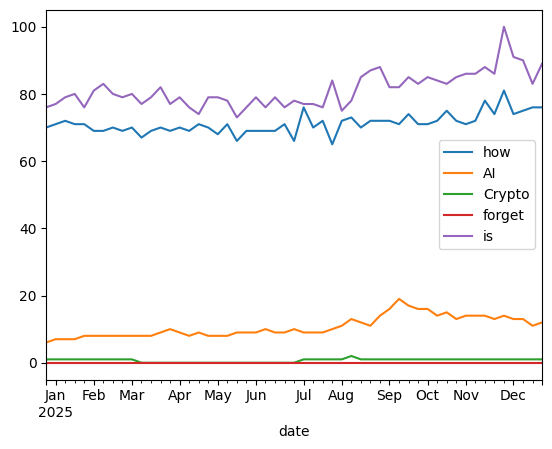

In [57]:
iot.plot()

In [58]:
iot.drop(columns=["isPartial"], inplace=True)
df = iot.reset_index().melt(
    id_vars="date",
    var_name="keyword",
    value_name="value"
)
df = df.sort_values(["keyword", "date"])
df.reset_index(inplace=True)
df.drop(columns=["index"], inplace=True)
df.head()

,date,keyword,value
0,2024-12-29,AI,6
1,2025-01-05,AI,7
2,2025-01-12,AI,7
3,2025-01-19,AI,7
4,2025-01-26,AI,8


In [59]:
df["velocity"] = (
    df.groupby("keyword")["value"]
      .diff()
)



df["velocity_short"] = (
    df.groupby("keyword")["value"]
      .transform(lambda x: x.rolling(3).mean().diff())
)

df["velocity_long"] = (
    df.groupby("keyword")["value"]
      .transform(lambda x: x.rolling(7).mean().diff())
)

# df["accelration_rolling_3_day"] = (
#     df.groupby("keyword")["value"]
#       .transform(lambda x: x.diff())
# )

df["acceleration"] = (
    df.groupby("keyword")["velocity"]
      .transform(lambda x: x.diff()))
df.head(10)

,date,keyword,value,velocity,velocity_short,velocity_long,acceleration
0,2024-12-29,AI,6,NaN,NaN,NaN,NaN
1,2025-01-05,AI,7,1.0,NaN,NaN,NaN
2,2025-01-12,AI,7,0.0,NaN,NaN,-1.0
3,2025-01-19,AI,7,0.0,0.333333,NaN,0.0
4,2025-01-26,AI,8,1.0,0.333333,NaN,1.0
5,2025-02-02,AI,8,0.0,0.333333,NaN,-1.0
6,2025-02-09,AI,8,0.0,0.333333,NaN,0.0
7,2025-02-16,AI,8,0.0,0.000000,0.285714,0.0
8,2025-02-23,AI,8,0.0,0.000000,0.142857,0.0
9,2025-03-02,AI,8,0.0,0.000000,0.142857,0.0


In [60]:
from scipy.stats import median_abs_deviation
def Zscore_robust(x):
    x = x.astype(float)
    median = x.median()
    mad = median_abs_deviation(x, nan_policy="omit")
    if mad == 0:
        return x - median 
    return (x- median) / mad

df["velocity_short_zscore"] = (
    df.groupby("keyword")["velocity_short"]
    .transform(Zscore_robust)
)

df["velocity_long_zscore"] = (
    df.groupby("keyword")["velocity_long"]
    .transform(Zscore_robust)
)

df["acceleration_zscore"] = (
    df.groupby("keyword")["acceleration"]
    .transform(Zscore_robust)
)


In [61]:
df.head(10)


,date,keyword,value,velocity,velocity_short,velocity_long,acceleration,velocity_short_zscore,velocity_long_zscore,acceleration_zscore
0,2024-12-29,AI,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-05,AI,7,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-12,AI,7,0.0,NaN,NaN,-1.0,NaN,NaN,-1.0
3,2025-01-19,AI,7,0.0,0.333333,NaN,0.0,1.0,NaN,0.0
4,2025-01-26,AI,8,1.0,0.333333,NaN,1.0,1.0,NaN,1.0
5,2025-02-02,AI,8,0.0,0.333333,NaN,-1.0,1.0,NaN,-1.0
6,2025-02-09,AI,8,0.0,0.333333,NaN,0.0,1.0,NaN,0.0
7,2025-02-16,AI,8,0.0,0.000000,0.285714,0.0,0.0,1.000000e+00,0.0
8,2025-02-23,AI,8,0.0,0.000000,0.142857,0.0,0.0,6.217249e-15,0.0
9,2025-03-02,AI,8,0.0,0.000000,0.142857,0.0,0.0,0.000000e+00,0.0


In [62]:
df.shape

(265, 10)

In [63]:
from scipy.stats import norm

def classify_regime(row):
    sz = row['velocity_short_zscore']
    lz = row['velocity_long_zscore']
    az = row['acceleration_zscore']

    if pd.isna(sz) or pd.isna(lz):
        return 'Insufficient Data'
    
    # Crossover signal: short momentum vs long momentum
    crossover = sz - lz  

    if sz > 2 and crossover > 0:
        return 'Spike'
    elif sz > 1 and crossover > 0:
        return 'Building'
    elif sz < -1.5 or (crossover < -1 and lz > 0):
        return 'Collapsing'
    else:
        return 'Quiet'

df['regime'] = df.apply(classify_regime, axis=1)

In [64]:
verdict_map = {
    'Spike':               ('🟢 ACT NOW',   'Strong real momentum. Publish immediately.'),
    'Building':            ('🟡 WATCH',     'Momentum building. Prepare content now.'),
    'Quiet':               ('⚪ WAIT',      'No real signal. Hold content.'),
    'Collapsing':          ('🔴 HOLD OFF',  'Trend reversing. Poor time to publish.'),
    'Insufficient Data':   ('⏳ NO SIGNAL', 'Not enough data yet.')
}

def print_verdict(df, keyword):
    kdf = df[df['keyword'] == keyword].copy()
    latest = kdf.iloc[-1]
    
    regime = latest['regime']
    signal, explanation = verdict_map[regime]
    
    # p-value from short z-score
    sz = latest['velocity_short_zscore']
    p = round(1 - norm.cdf(sz), 4) if not pd.isna(sz) else None
    
    print("=" * 45)
    print(f"  KEYWORD     : {keyword}")
    print(f"  DATE        : {latest['date']}")
    print(f"  TREND SCORE : {latest['value']}")
    print(f"  SHORT Z     : {round(sz, 2) if not pd.isna(sz) else 'N/A'}")
    print(f"  LONG Z      : {round(latest['velocity_long_zscore'], 2) if not pd.isna(latest['velocity_long_zscore']) else 'N/A'}")
    print(f"  P-VALUE     : {p if p else 'N/A'}")
    print(f"  REGIME      : {regime}")
    print(f"  VERDICT     : {signal}")
    print(f"  REASON      : {explanation}")
    print("=" * 45)

print_verdict(df, 'AI')

  KEYWORD     : AI
  DATE        : 2025-12-28 00:00:00
  TREND SCORE : 12
  SHORT Z     : -1.0
  LONG Z      : -3.0
  P-VALUE     : 0.8413
  REGIME      : Quiet
  VERDICT     : ⚪ WAIT
  REASON      : No real signal. Hold content.


In [65]:
from scipy.stats import norm
import pandas as pd

def build_summary(df):
    latest = (
        df.sort_values("date")
          .groupby("keyword")
          .tail(1)
          .copy()
    )

    latest["p_value"] = latest["velocity_short_zscore"].apply(
        lambda x: 1 - norm.cdf(x) if pd.notna(x) else None
    )

    latest["verdict"] = latest["regime"].map(lambda r: verdict_map[r][0])
    latest["reason"] = latest["regime"].map(lambda r: verdict_map[r][1])

    summary = latest[[
        "keyword",
        "date",
        "value",
        "velocity_short_zscore",
        "velocity_long_zscore",
        "p_value",
        "regime",
        "verdict"
    ]]

    return summary.sort_values("velocity_short_zscore", ascending=False)

summary = build_summary(df.reset_index())
summary

,keyword,date,value,velocity_short_zscore,velocity_long_zscore,p_value,regime,verdict
211,how,2025-12-28,76,1.0,2.0,0.158655,Quiet,⚪ WAIT
158,forget,2025-12-28,0,0.0,0.0,0.500000,Quiet,⚪ WAIT
105,Crypto,2025-12-28,1,0.0,0.0,0.500000,Quiet,⚪ WAIT
52,AI,2025-12-28,12,-1.0,-3.0,0.841345,Quiet,⚪ WAIT
264,is,2025-12-28,89,-1.0,0.5,0.841345,Collapsing,🔴 HOLD OFF


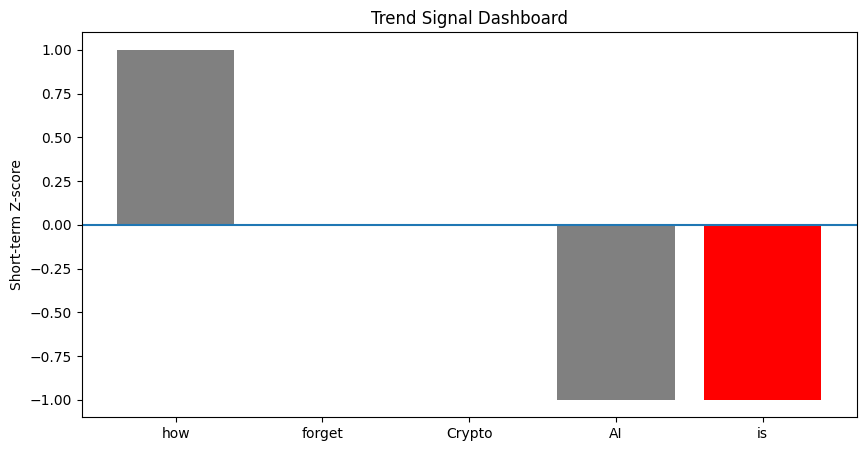

In [67]:
colors = summary["regime"].map({
    "Spike": "green",
    "Building": "gold",
    "Quiet": "gray",
    "Collapsing": "red",
    "Insufficient Data": "lightblue"
})

plt.figure(figsize=(10,5))
plt.bar(summary["keyword"], summary["velocity_short_zscore"], color=colors)
plt.axhline(0)
plt.title("Trend Signal Dashboard")
plt.ylabel("Short-term Z-score")
plt.show()

/tmp/ipykernel_12625/3045515244.py:70: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12625/3045515244.py:70: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12625/3045515244.py:70: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: G

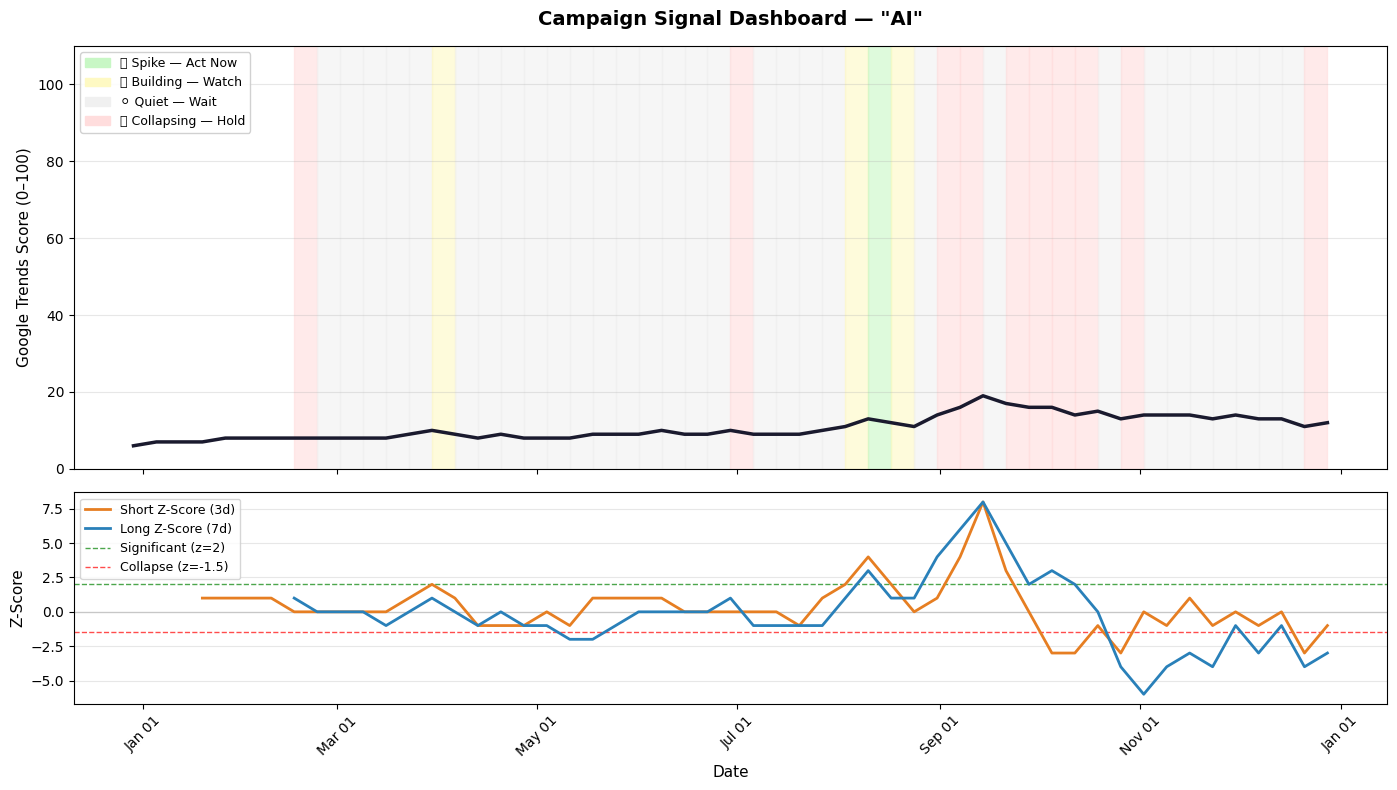

In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

regime_colors = {
    'Spike':             '#c8f7c5',
    'Building':          '#fef9c3',
    'Quiet':             '#f0f0f0',
    'Collapsing':        '#fdd',
    'Insufficient Data': '#ffffff'
}

def plot_keyword(df, keyword):
    kdf = df[df['keyword'] == keyword].copy()
    kdf['date'] = pd.to_datetime(kdf['date'])
    kdf = kdf.sort_values('date')

    fig, (ax1, ax2) = plt.subplots(
        2, 1, 
        figsize=(14, 8), 
        sharex=True,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    # ── Top panel: trend score + regime background ──
    for i in range(len(kdf) - 1):
        regime = kdf['regime'].iloc[i]
        ax1.axvspan(
            kdf['date'].iloc[i],
            kdf['date'].iloc[i + 1],
            color=regime_colors[regime],
            alpha=0.6
        )

    ax1.plot(kdf['date'], kdf['value'], 
             color='#1a1a2e', linewidth=2.5, label='Trend Score', zorder=3)
    ax1.set_ylabel('Google Trends Score (0–100)', fontsize=11)
    ax1.set_title(f'Campaign Signal Dashboard — "{keyword}"', 
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylim(0, 110)
    ax1.grid(axis='y', alpha=0.3)

    # ── Bottom panel: z-scores ──
    ax2.plot(kdf['date'], kdf['velocity_short_zscore'],
             color='#e67e22', linewidth=2, label='Short Z-Score (3d)', zorder=3)
    ax2.plot(kdf['date'], kdf['velocity_long_zscore'],
             color='#2980b9', linewidth=2, label='Long Z-Score (7d)', zorder=3)
    
    # significance threshold lines
    ax2.axhline(y=2,  color='green', linestyle='--', alpha=0.7, linewidth=1, label='Significant (z=2)')
    ax2.axhline(y=-1.5, color='red', linestyle='--', alpha=0.7, linewidth=1, label='Collapse (z=-1.5)')
    ax2.axhline(y=0,  color='gray', linestyle='-',  alpha=0.3, linewidth=1)
    
    ax2.set_ylabel('Z-Score', fontsize=11)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.grid(axis='y', alpha=0.3)
    ax2.legend(loc='upper left', fontsize=9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)

    # ── Regime legend ──
    patches = [
        mpatches.Patch(color='#c8f7c5', label='🟢 Spike — Act Now'),
        mpatches.Patch(color='#fef9c3', label='🟡 Building — Watch'),
        mpatches.Patch(color='#f0f0f0', label='⚪ Quiet — Wait'),
        mpatches.Patch(color='#fdd',    label='🔴 Collapsing — Hold')
    ]
    ax1.legend(handles=patches, loc='upper left', fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()

plot_keyword(df, 'AI')